# Statistical Validation of Business Insights

## ApexPlanet Data Analytics Internship | Task 4

### Objective

This notebook validates the business insights identified during Exploratory Data Analysis (Task 2) and Interactive Dashboarding (Task 3) using statistical techniques.

The analyses focus on evaluating relationships between sales variables, validating observed trends, and determining whether differences across customer segments, products, and regions are statistically significant.

The findings presented in this notebook provide quantitative evidence to support business recommendations and strategic decision-making.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from scipy import stats

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/processed/cleaned_dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Young
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Senior
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Senior
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Senior
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Adult


In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.month_name()

df["Year"] = df["Order_Date"].dt.year

# Dataset Summary

Statistical validation requires a complete understanding of the underlying dataset before conducting hypothesis testing.

The following summary presents the overall dataset characteristics used throughout the analysis.

In [4]:
summary = pd.DataFrame({

    "Metric":[
        "Observations",
        "Variables",
        "Unique Customers",
        "Unique Orders",
        "Products",
        "Categories",
        "Cities"
    ],

    "Value":[
        len(df),
        df.shape[1],
        df["Customer_ID"].nunique(),
        df["Order_ID"].nunique(),
        df["Product"].nunique(),
        df["Category"].nunique(),
        df["City"].nunique()
    ]

})

summary

,Metric,Value
0,Observations,1000
1,Variables,15
2,Unique Customers,947
3,Unique Orders,992
4,Products,6
5,Categories,5
6,Cities,8


# Statistical Validation Framework

The following business questions will be statistically evaluated.

1. Is Total Sales significantly influenced by Quantity Sold?

2. Does customer gender influence purchasing behavior?

3. Do customer age groups generate significantly different revenues?

4. Which product categories contribute the greatest business value?

5. Are regional sales differences consistent across cities?

6. Do monthly sales exhibit meaningful seasonal variation?

# Descriptive Statistical Analysis

Descriptive statistics provide an initial understanding of the numerical characteristics of the sales dataset. The measures of central tendency and dispersion summarize customer demographics, purchasing behavior, product pricing, and overall revenue distribution before conducting inferential statistical tests.

The histogram of **Total Sales** illustrates how revenue is distributed across all transactions, while the summary statistics quantify the variability and range of each numerical variable.

In [5]:
numerical_cols = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Total_Sales"
]

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,41.35300,13.683626,18.00,30.0000,41.000,53.0000,65.00
Quantity,1000.0,5.43500,2.838632,1.00,3.0000,5.000,8.0000,10.00
Unit_Price,1000.0,25486.78341,14179.402361,145.78,13895.7225,25398.740,37512.3825,49997.53
Total_Sales,1000.0,139399.43965,114100.051546,437.34,47066.6325,108594.025,203722.8825,493677.50


# Interpretation of Descriptive Statistics

### Customer Age

- The average customer age is **41.35 years**, with a median of **41 years**, indicating that the customer base is primarily composed of middle-aged adults.
- Customer ages range from **18 to 65 years**, providing representation across multiple demographic groups.
- The relatively balanced mean and median suggest that the age distribution is approximately symmetric.

---

### Purchase Quantity

- Customers purchase an average of **5.44 units per transaction**.
- The standard deviation of **2.84 units** indicates moderate variability in purchasing behavior.
- Most transactions involve between **3 and 8 units**, demonstrating relatively consistent order sizes.

---

### Unit Price

- The average product price is approximately **₹25,487**, while the median price is **₹25,399**.
- Prices range from **₹145.78** to nearly **₹50,000**, indicating substantial variation in product pricing across categories.
- The similarity between the mean and median suggests that product pricing is reasonably balanced despite the wide range.

---

### Total Sales

- The average transaction value is **₹139,399**, while the median transaction value is **₹108,594**.
- Since the **mean exceeds the median**, the revenue distribution is positively skewed, indicating the presence of several high-value transactions.
- Total sales range from **₹437** to **₹493,678**, demonstrating considerable variation in customer spending.

---

### Distribution Analysis

The histogram confirms that the distribution of **Total Sales** is **right-skewed (positively skewed)**.

Key observations include:

- Most transactions are concentrated below **₹200,000**.
- A relatively small number of high-value transactions create a long right tail.
- The presence of these large transactions increases the overall mean revenue.
- The distribution does not appear perfectly normal, suggesting that normality assumptions should be considered when selecting statistical tests.

---

### Business Implications

The descriptive analysis indicates substantial variability in transaction values and customer purchasing behavior.

From a business perspective:

- High-value transactions contribute disproportionately to overall revenue.
- Revenue optimization strategies should focus on identifying and retaining high-spending customers.
- The broad range of unit prices suggests opportunities for product segmentation and targeted pricing strategies.
- Customer age diversity supports segmentation-based marketing campaigns tailored to different demographic groups.

These observations provide the statistical foundation for the subsequent correlation analysis and hypothesis testing performed in this notebook.

# Revenue Distribution Analysis

The distribution of **Total Sales** was examined to understand the underlying characteristics of transaction values before performing inferential statistical analysis.

A histogram with a Kernel Density Estimation (KDE) curve was used to evaluate the shape, spread, and concentration of revenue across all sales transactions.

Understanding the distribution of revenue is essential because many statistical techniques assume specific distributional properties. The results obtained from this analysis help determine the suitability of subsequent hypothesis tests and guide the interpretation of business performance.

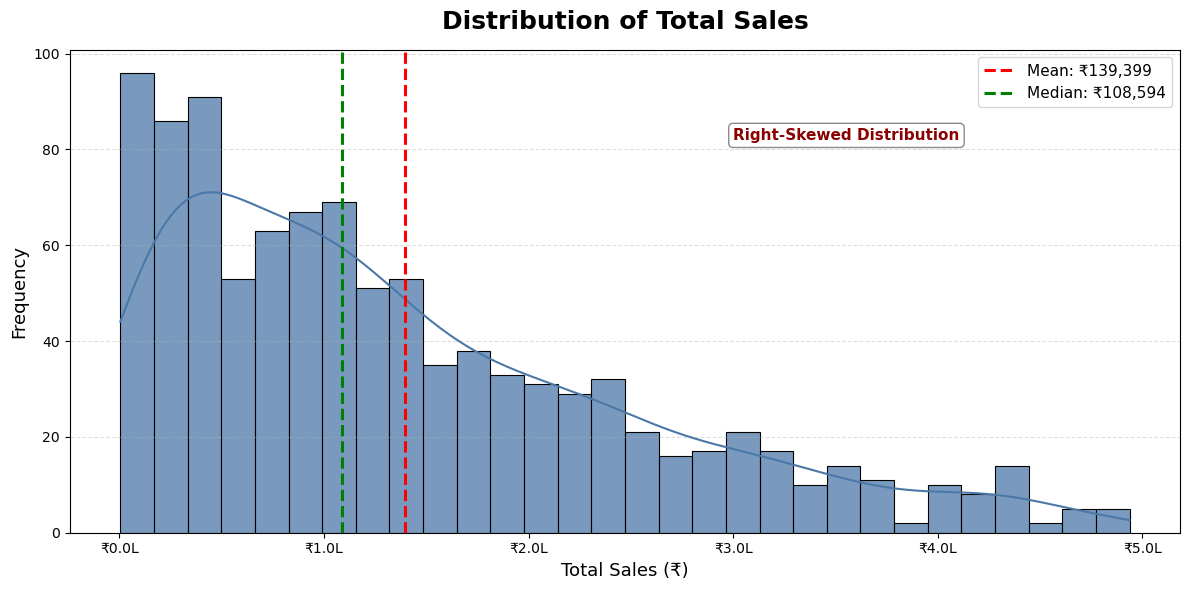

In [6]:
# Calculate statistics
mean_sales = df["Total_Sales"].mean()
median_sales = df["Total_Sales"].median()

# Function to display values in Lakhs
def lakh_formatter(x, pos):
    return f"₹{x/100000:.1f}L"

# Plot
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Total_Sales",
    bins=30,
    kde=True,
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.75
)

# Mean line
plt.axvline(
    mean_sales,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label=f"Mean: ₹{mean_sales:,.0f}"
)

# Median line
plt.axvline(
    median_sales,
    color="green",
    linestyle="--",
    linewidth=2.2,
    label=f"Median: ₹{median_sales:,.0f}"
)

# Annotation
plt.text(
    300000,
    82,
    "Right-Skewed Distribution",
    fontsize=11,
    fontweight="bold",
    color="darkred",
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.9,
        boxstyle="round"
    )
)

# Axis formatting
plt.gca().xaxis.set_major_formatter(FuncFormatter(lakh_formatter))

# Titles
plt.title(
    "Distribution of Total Sales",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Total Sales (₹)",
    fontsize=13
)

plt.ylabel(
    "Frequency",
    fontsize=13
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Legend
plt.legend(
    loc="upper right",
    fontsize=11,
    frameon=True
)

plt.tight_layout()

plt.show()

# Interpretation

The distribution of **Total Sales** exhibits a clear **positive (right) skew**, indicating that while most transactions generate moderate revenue, a relatively small number of high-value purchases contribute significantly to overall sales.

### Key Findings

- The majority of transactions are concentrated below **₹2.0 Lakhs**.
- The **mean transaction value (₹139,399)** is higher than the **median (₹108,594)**, confirming the presence of right-skewness.
- A small number of premium transactions create the long right tail of the distribution.
- Revenue values range from **₹437** to **₹493,678**, reflecting substantial variability in customer purchasing behavior.
- The distribution appears **unimodal**, suggesting a dominant purchasing pattern rather than multiple distinct customer segments.

### Statistical Implications

- The revenue distribution is **not perfectly normal**, primarily due to the influence of high-value transactions.
- Given the large sample size (**n = 1000**), parametric statistical methods remain appropriate, although their assumptions should be interpreted with care.
- These observations provide the basis for subsequent correlation analysis and hypothesis testing.

### Business Implications

The findings indicate that a relatively small group of high-spending customers contributes disproportionately to total revenue. Strengthening customer retention programs, targeted promotions, and premium product strategies for these customers can have a meaningful impact on overall business performance. Simultaneously, initiatives aimed at increasing the average spending of regular customers may further enhance revenue growth.

# Outlier Analysis

## Objective

Outlier analysis is performed to identify unusually high or low transaction values that may influence statistical measures such as the mean, standard deviation, and correlation coefficients.

In sales analytics, outliers are not always data quality issues. High-value transactions often represent premium customers or bulk purchases and may contribute significantly to overall business revenue.

The Interquartile Range (IQR) method is used to identify potential outliers in the **Total Sales** variable.

In [7]:
# Calculate Quartiles
Q1 = df["Total_Sales"].quantile(0.25)
Q3 = df["Total_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Detect Outliers
outliers = df[
    (df["Total_Sales"] < lower_bound) |
    (df["Total_Sales"] > upper_bound)
]

print("="*60)
print("Outlier Detection using IQR Method")
print("="*60)

print(f"Q1               : ₹{Q1:,.2f}")
print(f"Q3               : ₹{Q3:,.2f}")
print(f"IQR              : ₹{IQR:,.2f}")
print(f"Lower Bound      : ₹{lower_bound:,.2f}")
print(f"Upper Bound      : ₹{upper_bound:,.2f}")
print(f"Total Outliers   : {len(outliers)}")
print(f"Outlier %        : {(len(outliers)/len(df))*100:.2f}%")

Outlier Detection using IQR Method
Q1               : ₹47,066.63
Q3               : ₹203,722.88
IQR              : ₹156,656.25
Lower Bound      : ₹-187,917.74
Upper Bound      : ₹438,707.26
Total Outliers   : 19
Outlier %        : 1.90%


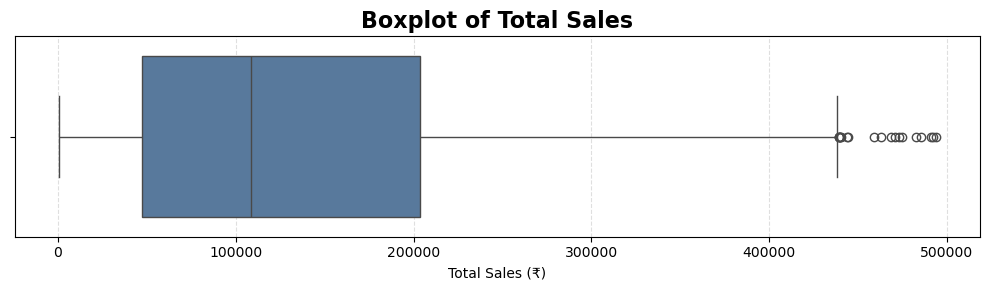

In [8]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["Total_Sales"],
    color="#4C78A8"
)

plt.title(
    "Boxplot of Total Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales (₹)")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [9]:
outliers.head(10)

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group,Month,Year
50,ORD100052,2025-09-09,CUST2062,Customer_254,58.0,Male,Patna,Book,Education,10,49367.75,493677.50,Middle Age,September,2025
81,ORD100083,2025-01-06,CUST8346,Customer_384,30.0,Male,Hyderabad,Laptop,Electronics,9,48845.50,439609.50,Young,January,2025
150,ORD100152,2025-02-08,CUST5188,Customer_286,53.0,Male,Gaya,Laptop,Electronics,9,48833.27,439499.43,Middle Age,February,2025
173,ORD100175,2025-06-07,CUST3564,Customer_267,41.0,Male,Patna,Rice,Grocery,9,49390.42,444513.78,Adult,June,2025
220,ORD100222,2025-07-13,CUST1711,Customer_36,20.0,Female,Bengaluru,Shoes,Fashion,10,49086.64,490866.40,Young,July,2025
364,ORD100366,2025-03-13,CUST9551,Customer_230,18.0,Male,Bengaluru,Mobile,Electronics,10,47493.59,474935.90,Young,March,2025
396,ORD100398,2025-03-07,CUST6600,Customer_242,58.0,Female,Bengaluru,Mobile,Electronics,9,48807.37,439266.33,Middle Age,March,2025
432,ORD100434,2025-06-10,CUST4982,Customer_370,33.0,Male,Delhi,Mobile,Electronics,10,43997.22,439972.20,Adult,June,2025
448,ORD100450,2025-02-13,CUST6714,Customer_31,41.0,Female,Patna,Book,Education,10,43946.96,439469.60,Adult,February,2025
462,ORD100464,2025-09-17,CUST1710,Customer_355,46.0,Female,Hyderabad,Book,Education,10,44045.66,440456.60,Middle Age,September,2025


# Interpretation

The Interquartile Range (IQR) method identified **19 potential outliers**, representing **1.90%** of the total transactions.

## Key Findings

- First Quartile (Q1): **₹47,066.63**
- Third Quartile (Q3): **₹203,722.88**
- Interquartile Range (IQR): **₹156,656.25**
- Upper Outlier Threshold: **₹438,707.26**

The boxplot reveals that the majority of transactions are concentrated within the expected revenue range, while a limited number of transactions exceed the upper threshold.

No lower-end outliers were detected because the calculated lower bound is negative, which is not applicable for sales revenue.

---

## Statistical Interpretation

The identified outliers correspond exclusively to **high-value sales transactions**.

These observations contribute to:

- Positive skewness in the revenue distribution
- Higher average transaction value
- Increased standard deviation

Although these transactions are statistically classified as outliers, they remain valid observations and accurately represent business operations.

---

## Business Interpretation

The outliers represent premium purchases involving:

- High unit prices
- Large order quantities
- High-value customers

Such transactions contribute significantly to total business revenue and should be retained for analysis.

Removing these observations would underestimate revenue performance and distort important business metrics.

Therefore, **no outliers were removed**, as they represent genuine business activity rather than data quality issues.

# Correlation Analysis

## Objective

Correlation analysis measures the strength and direction of linear relationships between numerical variables.

Understanding these relationships helps identify the key drivers of revenue generation and supports evidence-based business decisions.

For this analysis, the Pearson Correlation Coefficient is used to evaluate associations among customer age, purchase quantity, unit price, and total sales.

Correlation coefficients range from **-1 to +1**:

| Correlation | Interpretation |
|-------------|---------------|
| +1.00 | Perfect Positive Relationship |
| +0.70 to +0.99 | Strong Positive Relationship |
| +0.30 to +0.69 | Moderate Positive Relationship |
| -0.29 to +0.29 | Weak or No Relationship |
| -0.30 to -0.69 | Moderate Negative Relationship |
| -0.70 to -1.00 | Strong Negative Relationship |

A positive correlation indicates that both variables increase together, whereas a negative correlation indicates that one variable decreases as the other increases.

In [10]:
corr_matrix = df[
    [
        "Age",
        "Quantity",
        "Unit_Price",
        "Total_Sales"
    ]
].corr()

corr_matrix.round(3)

,Age,Quantity,Unit_Price,Total_Sales
Age,1.000,-0.028,-0.012,0.001
Quantity,-0.028,1.000,0.022,0.647
Unit_Price,-0.012,0.022,1.000,0.686
Total_Sales,0.001,0.647,0.686,1.000


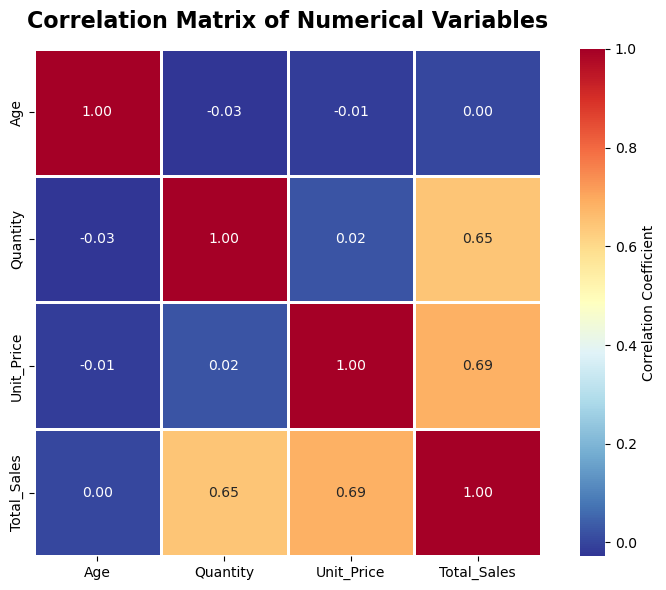

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=1,
    square=True,
    cbar_kws={"label":"Correlation Coefficient"}
)

plt.title(
    "Correlation Matrix of Numerical Variables",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.show()

# Correlation Analysis: Interpretation

The correlation matrix provides insights into the strength and direction of relationships among the numerical variables included in the sales dataset.

## Key Findings

### Total Sales and Unit Price (r = 0.686)

- A moderately strong positive correlation exists between **Unit Price** and **Total Sales**.
- Higher-priced products tend to generate greater revenue per transaction.
- This is the strongest relationship observed among the numerical variables.

### Total Sales and Quantity (r = 0.647)

- A moderately strong positive correlation exists between **Quantity** and **Total Sales**.
- Customers purchasing more units generally contribute to higher transaction values.
- This relationship confirms that order size is an important revenue driver.

### Quantity and Unit Price (r = 0.022)

- The correlation is close to zero, indicating that customers purchasing larger quantities are not necessarily buying more expensive products.
- Quantity purchased and product pricing operate largely independently.

### Age and Sales Variables

Customer age exhibits negligible correlation with Quantity, Unit Price, and Total Sales.

This suggests that customer age alone is not a significant predictor of purchasing behavior or revenue generation.

---

## Business Insights

The analysis identifies two primary drivers of revenue:

- Product Pricing
- Purchase Quantity

Business strategies focused on increasing average order size and promoting premium products are likely to have the greatest impact on revenue growth.

# Pearson Correlation Test

While the correlation matrix provides pairwise relationships among variables, the Pearson Correlation Test statistically evaluates the strength and significance of the relationship between **Quantity Sold** and **Total Sales**.

### Hypotheses

**Null Hypothesis (H₀)**

There is no statistically significant linear relationship between Quantity Sold and Total Sales.

**Alternative Hypothesis (H₁)**

There is a statistically significant positive linear relationship between Quantity Sold and Total Sales.

In [12]:
corr, p_value = stats.pearsonr(
    df["Quantity"],
    df["Total_Sales"]
)

print("="*60)
print("Pearson Correlation Test")
print("="*60)

print(f"Correlation Coefficient : {corr:.4f}")
print(f"P-value                 : {p_value:.10f}")

Pearson Correlation Test
Correlation Coefficient : 0.6466
P-value                 : 0.0000000000


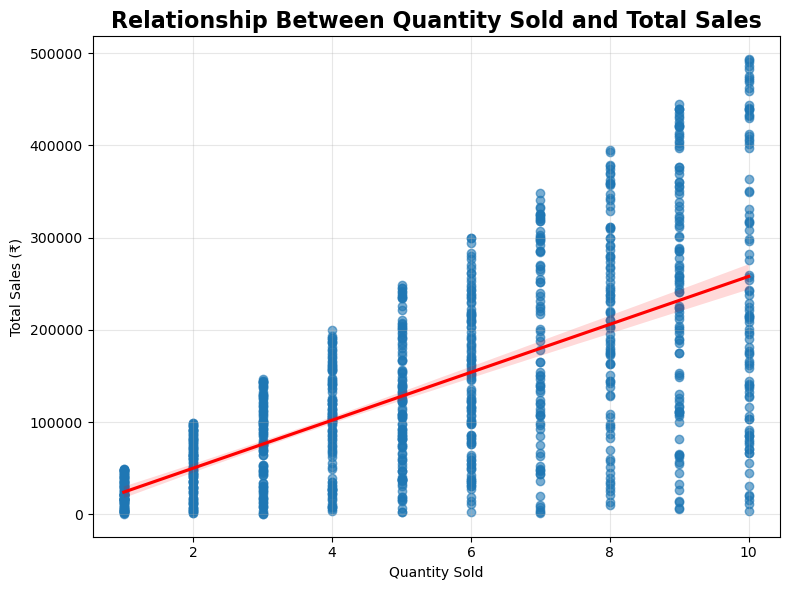

In [13]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Quantity",
    y="Total_Sales",
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)

plt.title(
    "Relationship Between Quantity Sold and Total Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Quantity Sold")

plt.ylabel("Total Sales (₹)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Pearson Correlation Test: Interpretation

The Pearson Correlation Test was conducted to determine whether a statistically significant linear relationship exists between **Quantity Sold** and **Total Sales**.

## Hypothesis

**Null Hypothesis (H₀):**
There is no significant linear relationship between Quantity Sold and Total Sales.

**Alternative Hypothesis (H₁):**
There is a significant positive linear relationship between Quantity Sold and Total Sales.

---

## Results

- **Correlation Coefficient (r):** 0.6466
- **P-value:** < 0.0001

---

## Statistical Decision

Since the p-value is significantly lower than the conventional significance level of **0.05**, the null hypothesis is rejected.

The results provide strong statistical evidence of a positive linear relationship between Quantity Sold and Total Sales.

---

## Business Interpretation

The analysis confirms that increasing the number of products purchased in a transaction directly contributes to higher revenue generation.

Potential business strategies include:

- Product bundling
- Cross-selling complementary products
- Volume-based discounts
- Loyalty programs encouraging larger purchases

These initiatives can increase average basket size and drive sustained revenue growth.

# Independent Sample T-Test

## Objective

The Independent Sample T-Test is used to determine whether there is a statistically significant difference in the average transaction value between two independent customer groups.

In this analysis, customer spending is compared based on **Gender**.

Understanding whether purchasing behavior differs between male and female customers enables businesses to evaluate the effectiveness of demographic-based marketing strategies and customer segmentation.

---

## Research Hypothesis

### Null Hypothesis (H₀)

There is **no statistically significant difference** in the average Total Sales between male and female customers.

### Alternative Hypothesis (H₁)

There **is a statistically significant difference** in the average Total Sales between male and female customers.

In [14]:
gender_summary = (
    df.groupby("Gender")["Total_Sales"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

gender_summary

,count,mean,median,std,min,max
Gender,,,,,,
Female,489,136883.21,108470.60,111788.03,1005.21,490866.4
Male,511,141807.34,109237.86,116327.98,437.34,493677.5


# Gender-wise Revenue Distribution

Before conducting the hypothesis test, the distribution of Total Sales across gender groups is visualized.

The boxplot summarizes:

- Median transaction value
- Interquartile Range (IQR)
- Overall spread
- Potential outliers

This visualization provides an initial understanding of whether noticeable differences exist between the two customer groups.

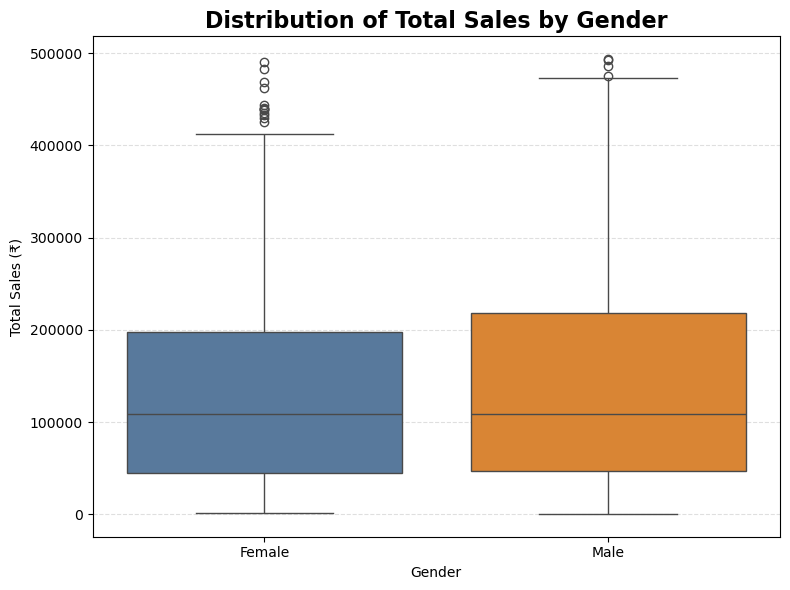

In [15]:

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Gender",
    y="Total_Sales",
    palette=["#4C78A8", "#F58518"]
)

plt.title(
    "Distribution of Total Sales by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Total Sales (₹)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [16]:
male_sales = df[df["Gender"] == "Male"]["Total_Sales"]
female_sales = df[df["Gender"] == "Female"]["Total_Sales"]

t_stat, p_value = stats.ttest_ind(
    male_sales,
    female_sales,
    equal_var=False
)

print("="*60)
print("Independent Sample T-Test")
print("="*60)

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")

Independent Sample T-Test
T-Statistic : 0.6826
P-Value     : 0.495011


In [17]:
alpha = 0.05

print("="*60)

if p_value < alpha:
    print("Decision : Reject the Null Hypothesis (H₀)")
else:
    print("Decision : Fail to Reject the Null Hypothesis (H₀)")

print("="*60)

Decision : Fail to Reject the Null Hypothesis (H₀)


# Interpretation of Independent Sample T-Test

The Independent Sample T-Test was conducted to determine whether the average transaction value differs significantly between male and female customers.

## Summary Statistics

| Gender | Customers | Mean Sales (₹) | Median Sales (₹) | Standard Deviation (₹) |
|---------|----------:|---------------:|-----------------:|-----------------------:|
| Female | 489 | 136,883.21 | 108,470.60 | 111,788.03 |
| Male | 511 | 141,807.34 | 109,237.86 | 116,327.98 |

Although male customers recorded a slightly higher average transaction value than female customers, the difference is relatively small.

---

## Hypothesis Testing Results

- **T-Statistic:** 0.6826
- **P-Value:** 0.4950
- **Significance Level (α):** 0.05

Since the **p-value (0.4950)** is substantially greater than the significance level of **0.05**, the null hypothesis cannot be rejected.

Therefore, there is **no statistically significant difference** in the average Total Sales between male and female customers.

---

## Statistical Conclusion

The observed variation in average spending between genders is likely due to natural sampling variability rather than a meaningful underlying difference in purchasing behavior.

Gender does not appear to be a significant determinant of customer spending within this sales dataset.

---

## Business Implications

The findings indicate that gender-based segmentation is unlikely to provide substantial business value for revenue optimization.

Instead, business efforts should prioritize variables that demonstrate stronger relationships with revenue, such as:

- Product category
- Product pricing
- Purchase quantity
- Customer purchasing frequency
- Geographic location

These factors are expected to have a greater influence on overall business performance than customer gender.

# One-Way Analysis of Variance (ANOVA)

## Objective

One-Way ANOVA is used to determine whether the average transaction value differs significantly across multiple customer age groups.

Unlike the Independent Sample T-Test, which compares two groups, ANOVA compares the means of **three or more independent groups** simultaneously.

Understanding spending behavior across different age segments enables businesses to develop targeted marketing strategies, personalized product recommendations, and customer segmentation initiatives.

---

## Research Hypothesis

### Null Hypothesis (H₀)

There is **no statistically significant difference** in the average Total Sales among the customer age groups.

### Alternative Hypothesis (H₁)

At least one customer age group has a statistically different average Total Sales.

In [18]:
age_summary = (
    df.groupby("Age_Group")["Total_Sales"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

age_summary

,count,mean,median,std,min,max
Age_Group,,,,,,
Adult,332,139442.78,110428.13,114638.34,1229.02,492174.10
Middle Age,295,138310.46,115132.52,113154.85,767.61,493677.50
Senior,105,144268.34,109150.30,116714.98,437.34,434820.24
Young,268,138636.85,104298.44,114029.25,1005.21,490866.40


# Revenue Distribution Across Age Groups

Before conducting the ANOVA test, the distribution of Total Sales is visualized for each age group.

The boxplot summarizes:

- Median transaction value
- Interquartile Range (IQR)
- Distribution spread
- Potential outliers

This provides an initial indication of whether customer spending varies across different age segments.

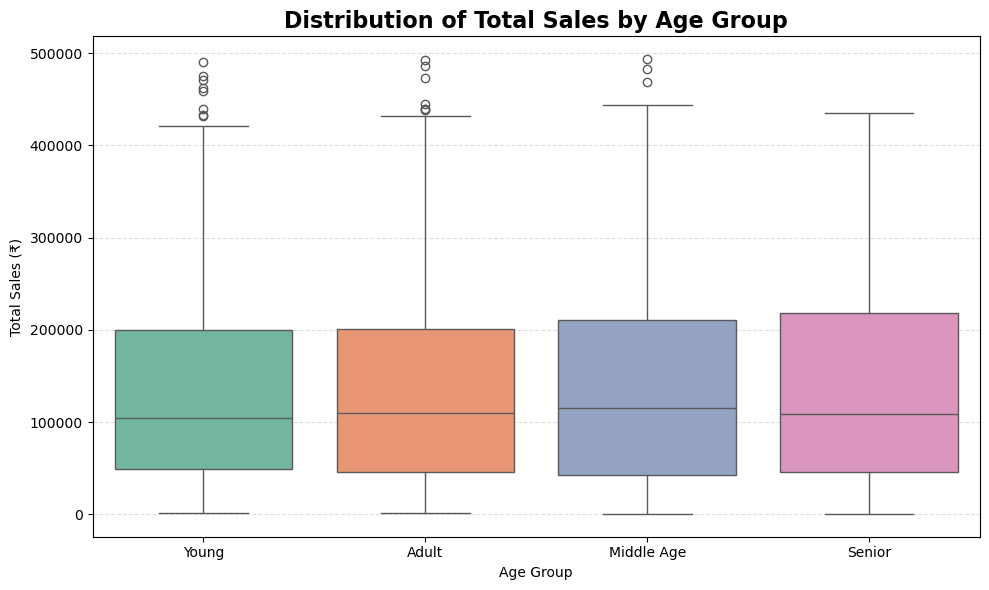

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Age_Group",
    y="Total_Sales",
    order=["Young","Adult","Middle Age","Senior"],
    palette="Set2"
)

plt.title(
    "Distribution of Total Sales by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Total Sales (₹)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

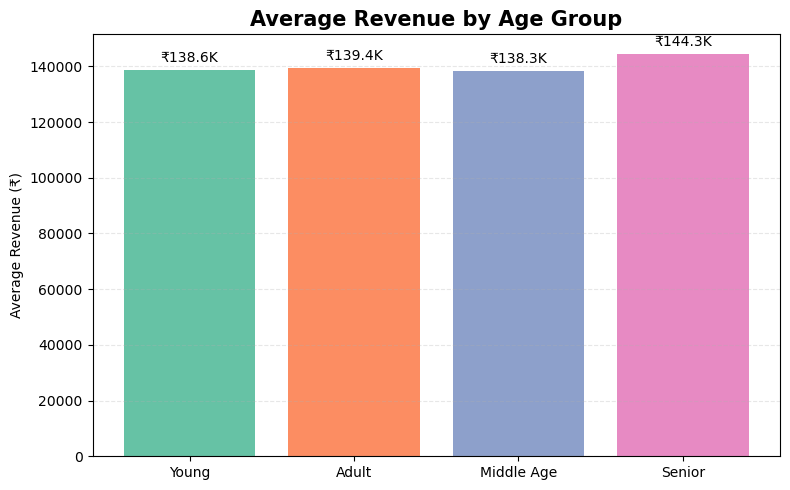

In [20]:
age_mean = (
    df.groupby("Age_Group")["Total_Sales"]
      .mean()
      .reindex(["Young", "Adult", "Middle Age", "Senior"])
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    age_mean.index,
    age_mean.values,
    color=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3000,
        f"₹{bar.get_height()/1000:.1f}K",
        ha="center",
        fontsize=10
    )

plt.title(
    "Average Revenue by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Average Revenue (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
young = df[df["Age_Group"]=="Young"]["Total_Sales"]
adult = df[df["Age_Group"]=="Adult"]["Total_Sales"]
middle = df[df["Age_Group"]=="Middle Age"]["Total_Sales"]
senior = df[df["Age_Group"]=="Senior"]["Total_Sales"]

f_stat, p_value = stats.f_oneway(
    young,
    adult,
    middle,
    senior
)

print("="*60)
print("One-Way ANOVA")
print("="*60)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")

One-Way ANOVA
F-Statistic : 0.0765
P-Value     : 0.972686


In [22]:
alpha = 0.05

print("="*60)

if p_value < alpha:
    print("Decision : Reject the Null Hypothesis (H₀)")
else:
    print("Decision : Fail to Reject the Null Hypothesis (H₀)")

print("="*60)

Decision : Fail to Reject the Null Hypothesis (H₀)


# Interpretation of One-Way ANOVA

The One-Way ANOVA was conducted to determine whether customer age groups exhibit statistically significant differences in average transaction value.

## Summary Statistics

| Age Group | Customers | Mean Sales (₹) | Median Sales (₹) | Standard Deviation (₹) |
|------------|----------:|---------------:|-----------------:|-----------------------:|
| Young | 268 | 138,636.85 | 104,298.44 | 114,029.25 |
| Adult | 332 | 139,442.78 | 110,428.13 | 114,638.34 |
| Middle Age | 295 | 138,310.46 | 115,132.52 | 113,154.85 |
| Senior | 105 | 144,268.34 | 109,150.30 | 116,714.98 |

Although the Senior customer group records the highest average transaction value, the differences among the four age groups are relatively small.

---

## Hypothesis Testing Results

- **F-Statistic:** 0.0765
- **P-Value:** 0.9727
- **Significance Level (α):** 0.05

Since the **p-value (0.9727)** is substantially greater than **0.05**, the null hypothesis cannot be rejected.

Therefore, there is **no statistically significant difference** in average Total Sales across the customer age groups.

---

## Statistical Conclusion

The observed differences in average revenue among Young, Adult, Middle Age, and Senior customers are likely due to random variation rather than genuine differences in purchasing behavior.

Customer age does not significantly influence transaction value within this dataset.

---

## Business Implications

The findings indicate that age-based customer segmentation alone is unlikely to improve revenue optimization.

Instead, organizations should prioritize segmentation based on variables that have demonstrated stronger statistical relationships with revenue, including:

- Product category
- Unit price
- Purchase quantity
- Geographic location
- Customer purchasing frequency

These variables are expected to provide greater business value than age-based targeting.

# Confidence Interval Estimation

## Objective

A confidence interval provides a range of plausible values within which the true population mean is expected to lie with a specified level of confidence.

Unlike a single point estimate, confidence intervals quantify the uncertainty associated with sample estimates and provide a more reliable basis for business decision-making.

For this analysis, a **95% Confidence Interval** is calculated for the average Total Sales.

---

## Why Confidence Intervals?

Confidence intervals help answer the following business question:

> **"Based on the available sales data, within what range is the true average transaction value likely to fall?"**

This information supports forecasting, budgeting, revenue planning, and performance benchmarking.

In [23]:
from scipy.stats import t
import numpy as np

# Sample Statistics
sample_size = len(df)
sample_mean = df["Total_Sales"].mean()
sample_std = df["Total_Sales"].std(ddof=1)

# Standard Error
standard_error = sample_std / np.sqrt(sample_size)

# 95% Confidence Level
confidence = 0.95

# Critical t-value
t_critical = t.ppf(
    (1 + confidence) / 2,
    df=sample_size - 1
)

# Margin of Error
margin_error = t_critical * standard_error

# Confidence Interval
lower_ci = sample_mean - margin_error
upper_ci = sample_mean + margin_error

print("="*65)
print("95% Confidence Interval for Mean Total Sales")
print("="*65)

print(f"Sample Size           : {sample_size}")
print(f"Sample Mean           : ₹{sample_mean:,.2f}")
print(f"Sample Standard Dev.  : ₹{sample_std:,.2f}")
print(f"Standard Error        : ₹{standard_error:,.2f}")
print(f"Margin of Error       : ₹{margin_error:,.2f}")

print("\nConfidence Interval")

print(f"Lower Limit           : ₹{lower_ci:,.2f}")
print(f"Upper Limit           : ₹{upper_ci:,.2f}")

95% Confidence Interval for Mean Total Sales
Sample Size           : 1000
Sample Mean           : ₹139,399.44
Sample Standard Dev.  : ₹114,100.05
Standard Error        : ₹3,608.16
Margin of Error       : ₹7,080.44

Confidence Interval
Lower Limit           : ₹132,319.00
Upper Limit           : ₹146,479.88


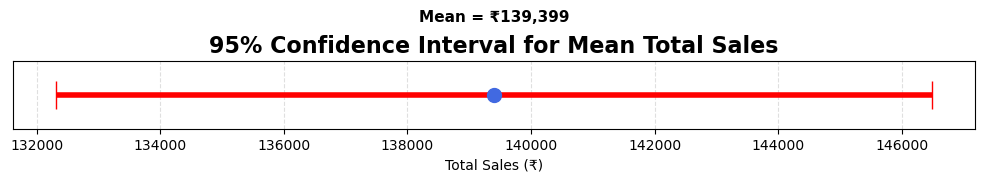

In [24]:
plt.figure(figsize=(10,2.8))

plt.errorbar(
    x=sample_mean,
    y=0,
    xerr=margin_error,
    fmt="o",
    color="royalblue",
    ecolor="red",
    elinewidth=4,
    capsize=10,
    markersize=10
)

plt.text(
    sample_mean,
    0.12,
    f"Mean = ₹{sample_mean:,.0f}",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.yticks([])

plt.title(
    "95% Confidence Interval for Mean Total Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales (₹)")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Interpretation of Confidence Interval

A 95% Confidence Interval was estimated for the average Total Sales to quantify the uncertainty around the sample mean.

## Summary Statistics

| Metric | Value |
|--------|-------:|
| Sample Size | 1,000 |
| Sample Mean | ₹139,399.44 |
| Standard Deviation | ₹114,100.05 |
| Standard Error | ₹3,608.16 |
| Margin of Error | ₹7,080.44 |
| Lower Confidence Limit | ₹132,319.00 |
| Upper Confidence Limit | ₹146,479.88 |

---

## Statistical Interpretation

The estimated **95% Confidence Interval** for the average Total Sales ranges from **₹132,319.00** to **₹146,479.88**.

This indicates that, based on the sample of 1,000 transactions, we are **95% confident** that the true population mean Total Sales lies within this interval.

The relatively narrow confidence interval suggests that the sample provides a reliable estimate of the average transaction value.

---

## Business Interpretation

The confidence interval provides a realistic estimate of expected customer spending and can support:

- Revenue forecasting
- Sales target planning
- Budget allocation
- Business performance benchmarking
- Strategic decision-making

The estimated average transaction value of approximately **₹139.4K** can therefore be considered a stable and representative measure of customer spending for this dataset.

# Conclusion

This notebook successfully validated the key business insights identified during Exploratory Data Analysis and Interactive Dashboarding through rigorous statistical techniques.

The analyses demonstrated that revenue generation is primarily influenced by transactional factors such as product pricing and purchase quantity, while customer demographic variables showed limited statistical impact.

The statistical evidence presented throughout this notebook provides a strong analytical foundation for strategic planning, customer segmentation, and business intelligence initiatives.

These validated insights will serve as the basis for the final business storytelling and executive presentation in the subsequent phase of the project.